In [1]:
import os
import xarray as xr
import numpy as np

In [8]:
day_da = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/FWI_HPB_NAT_m001.nc')

In [3]:
def fire_season(month):
    return (month >= 5) & (month <= 10)

In [8]:
for scen in ['HPB','HPB_NAT']:
    print(scen)
    for num in range(1,101):
        num_string = '0' + str(num) if num > 9 else '00' + str(num)
        if num == 100:
            num_string = '100'
            
        print(num_string)
        
        day_FWI = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/FWI_'+scen+'_m'+num_string+'.nc')
        
        months_selected = day_FWI.sel(time=fire_season(day_FWI['time.month']))
        fire_season_da = months_selected.resample(time ='A').mean('time')
        
        fire_season_da.to_netcdf('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_'+scen+'_m'+num_string+'.nc')

        

HPB
001
002
003
004
005


KeyboardInterrupt: 

In [11]:
day = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/FWI_HPB_m001.nc')
FS = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_m001.nc')

In [12]:
months_selected = day.sel(time=fire_season(day_FWI['time.month']))


In [15]:
months_selected.time.dt.month

<xarray.DataArray 'month' (time: 13064)>
array([ 5,  5,  5, ..., 10, 10, 10])
Coordinates:
  * time     (time) datetime64[ns] 1951-05-01 1951-05-02 ... 2021-10-31

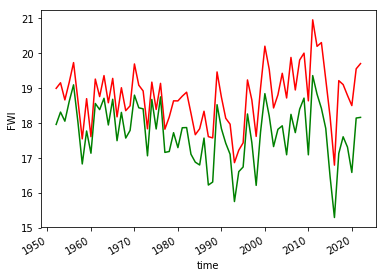

In [54]:
# ALL 6 month fire season
day_FWI = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/FWI_HPB_ensMean.nc')
months_selected = day_FWI.sel(time=fire_season(day_FWI['time.month']))
HPB_fire_season_da = months_selected.resample(time ='A').mean('time')

# NAT 6 month fire season
day_FWI = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/FWI_HPB_NAT_ensMean.nc')
months_selected = day_FWI.sel(time=fire_season(day_FWI['time.month']))
HPB_NAT_fire_season_da = months_selected.resample(time ='A').mean('time')

HPB_fire_season_da.mean(['latitude','longitude']).plot(c='red')
HPB_NAT_fire_season_da.mean(['latitude','longitude']).plot(c='green')

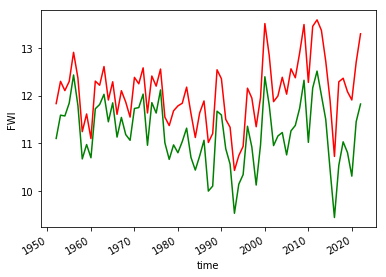

In [53]:
# ALL annual
day_FWI = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/FWI_HPB_ensMean.nc')
HPB_annual_da = day_FWI.resample(time ='A').mean('time')

# NAT annual
day_FWI = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/FWI_HPB_NAT_ensMean.nc')
HPB_NAT_annual_da = day_FWI.resample(time ='A').mean('time')

HPB_annual_da.mean(['latitude','longitude']).plot(c='red')
HPB_NAT_annual_da.mean(['latitude','longitude']).plot(c='green')

In [45]:
fire_season_da.isel(time=-1)

<xarray.DataArray 'FWI' (lev: 1, latitude: 92, longitude: 59)>
array([[[        nan,         nan,         nan, ...,         nan,
         11.19932638,  5.00638452],
        [        nan,         nan,         nan, ...,         nan,
         12.39362115, 11.63472277],
        [        nan,         nan,         nan, ...,         nan,
         14.91616296, 17.08653684],
        ...,
        [        nan,         nan,         nan, ...,  5.15490268,
          5.02879557,  4.93128856],
        [        nan,         nan,         nan, ...,  2.45074582,
          2.54541366,  2.39608593],
        [        nan,         nan,         nan, ...,  1.60904172,
          1.38886366,  1.51486919]]])
Coordinates:
    time       datetime64[ns] 2021-12-31
  * longitude  (longitude) float64 222.8 223.3 223.9 224.4 ... 254.2 254.8 255.4
  * latitude   (latitude) float64 19.94 20.5 21.06 21.62 ... 69.92 70.48 71.05
Dimensions without coordinates: lev

In [ ]:
'''
Mask global 2011-2021 d4PDF data to study region:
NZ
W North America: lat (19.9376, 71.045), lon (222.75, 255.375)
'''

for scen in ['HPB','HPB_NAT']:
    for var in ['TA_max','WIND','PRECIPI','RHA_min']:
        
        for num in range(1,101):
            num_string = '0' + str(num) if num > 9 else '00' + str(num)
            if num == 100:
                num_string = '100'
                
            infile = '/nesi/project/niwa02986/queenle/data/d4pdf/global/'+scen+'/day/' + var + '/' + var + '_Aday_d4PDF_'+scen+'_m'+num_string+'_2011-2021.nc'
            outfile = '/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/'+scen+'/'+var.split('_')[0]+'/decade/'+var.split('_')[0]+'_Aday_d4PDF_'+scen+'_m'+num_string+'_2011-2021.nc'
            
            os.system('cdo sellonlatbox,222.75,255.375,19.93757,71.04504 '+infile+' '+outfile)
            

In [ ]:
'''
Merge 1951-2011 and 2011-2021 netcdfs
'''

os.system('export SKIP_SAME_TIME=1')

for scen in ['HPB','HPB_NAT']:
    for var in ['TA','WIND','PRECIPI','RHA']:
        
        for num in range(1,101):
            num_string = '0' + str(num) if num > 9 else '00' + str(num)
            if num == 100:
                num_string = '100'
            
            if scen == 'HPB':
                samfile = '/nesi/project/niwa02986/deansm/data/d4pdf/WNAmerica/'+scen+'/day/' + var + '/' + var + '_Aday_d4PDF_'+scen+'_m'+num_string+'_1951-2011.nc'
            elif scen == 'HPB_NAT':
                samfile = '/nesi/project/niwa02986/deansm/data/d4pdf/WNAmerica/'+scen+'/day/' + var + '/' + var + '_Aday_d4PDF_'+scen+'_m'+num_string+'_1951-2010.nc'

            laurafile = '/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/'+scen+'/'+var+'/decade/'+var+'_Aday_d4PDF_'+scen+'_m'+num_string+'_2011-2021.nc'
            outfile = '/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/'+scen+'/'+var+'/'+var+'_Aday_d4PDF_'+scen+'_m'+num_string+'_1951-2021.nc'
            
            os.system('cdo mergetime ' + samfile + ' ' + laurafile + ' ' + outfile)
            
        break
        
    break
    

In [ ]:
'''
Testing results
'''

test = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/HPB/RHA/RHA_Aday_d4PDF_HPB_m001_1951-2021.nc')

test.sel(time='2011')